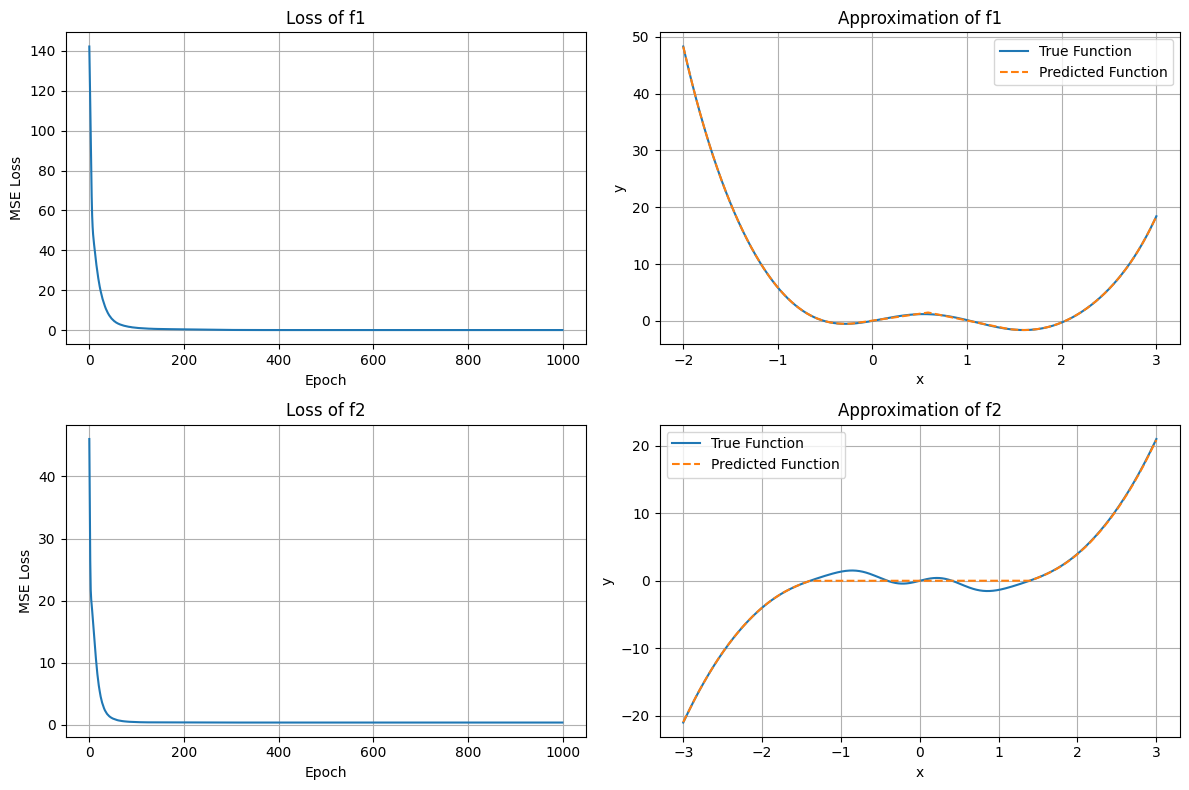

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def f1(x):
    return x**4 - 3 * x**3 + 2 * x**2 + np.sin(3 * x)

def f2(x):
    return x**3 - 2 * x + np.exp(-x**2) * np.sin(5 * x)

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )
    return model

def train_model(func, x_range, epochs=1000):
    x = np.linspace(x_range[0], x_range[1], 1000).reshape(-1, 1).astype(np.float32)
    y = func(x).astype(np.float32)

    model = build_model()
    history = model.fit(x, y, epochs=epochs, verbose=0)
    y_pred = model.predict(x, verbose=0)

    return x, y, y_pred, history.history['loss']

# 训练两个函数
x1, y1, y1_pred, loss1 = train_model(f1, (-2, 3), epochs=1000)
x2, y2, y2_pred, loss2 = train_model(f2, (-3, 3), epochs=1000)

# 绘图
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(loss1)
plt.title('Loss of f1')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(x1, y1, label='True Function')
plt.plot(x1, y1_pred, '--', label='Predicted Function')
plt.title('Approximation of f1')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(loss2)
plt.title('Loss of f2')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(x2, y2, label='True Function')
plt.plot(x2, y2_pred, '--', label='Predicted Function')
plt.title('Approximation of f2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()